# 1. Basic

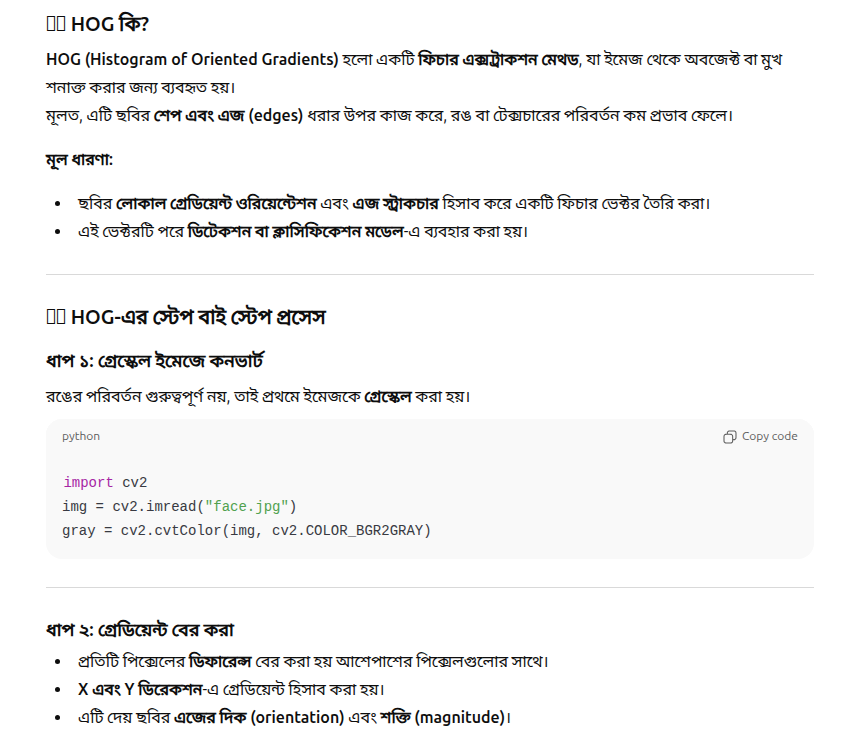

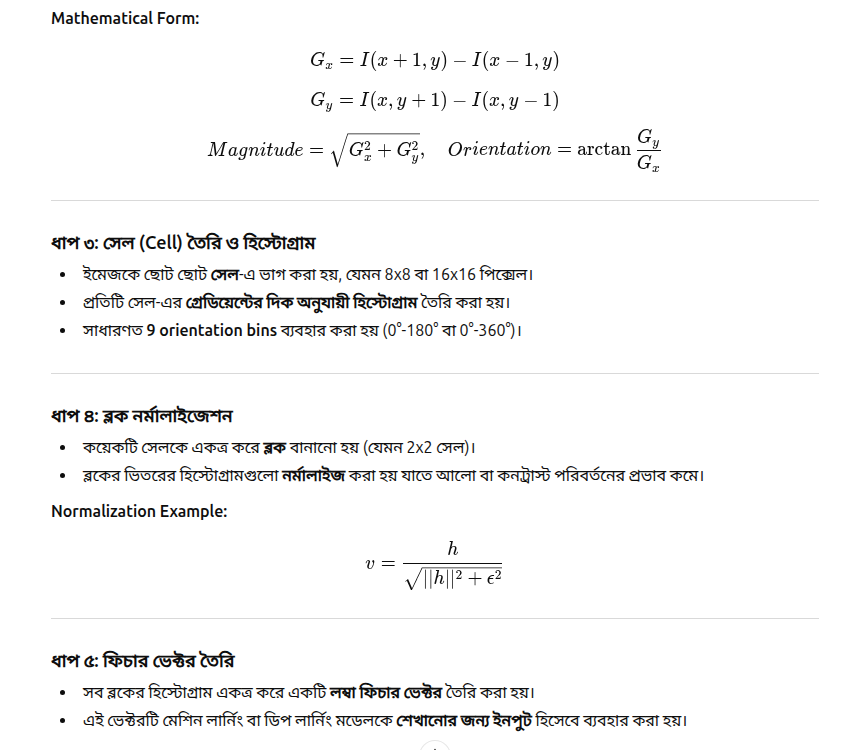

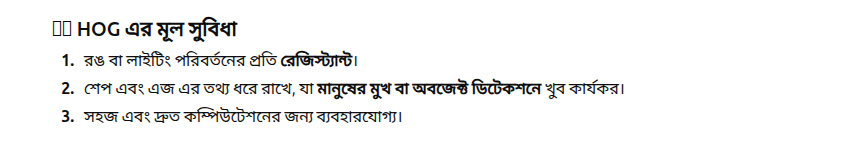

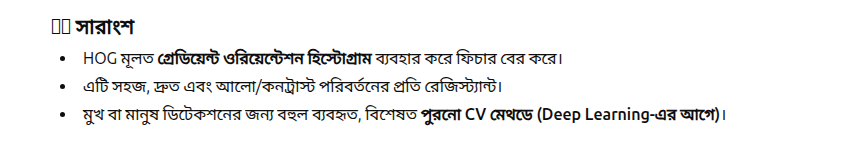

**Note**

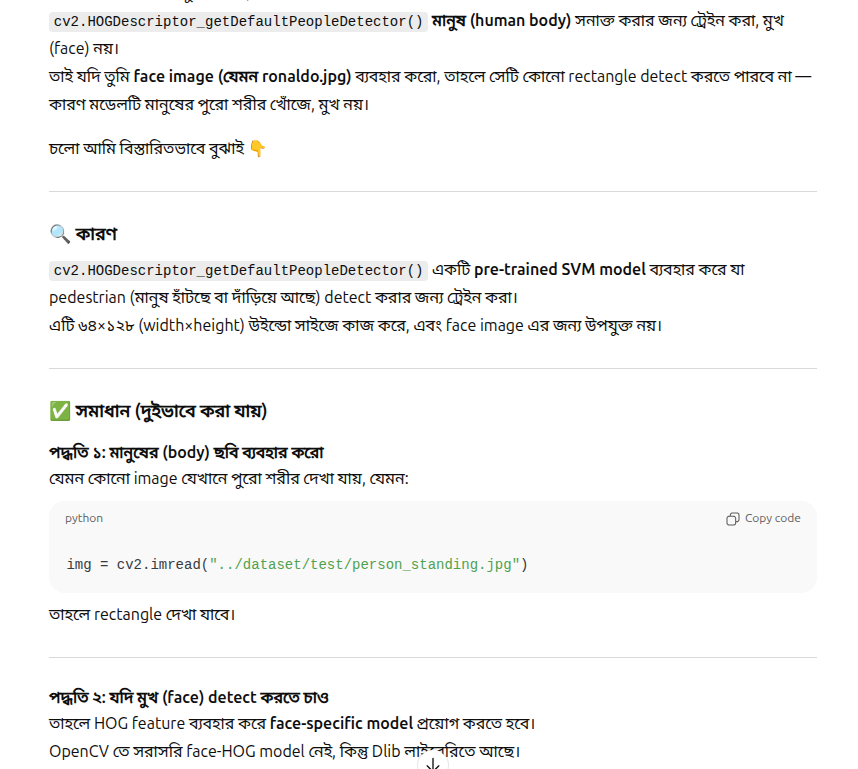

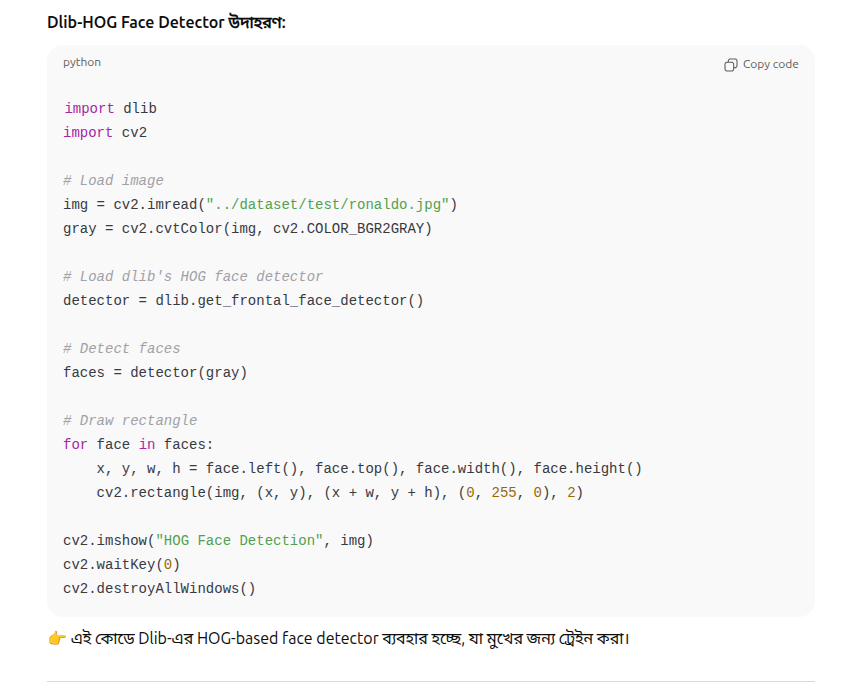

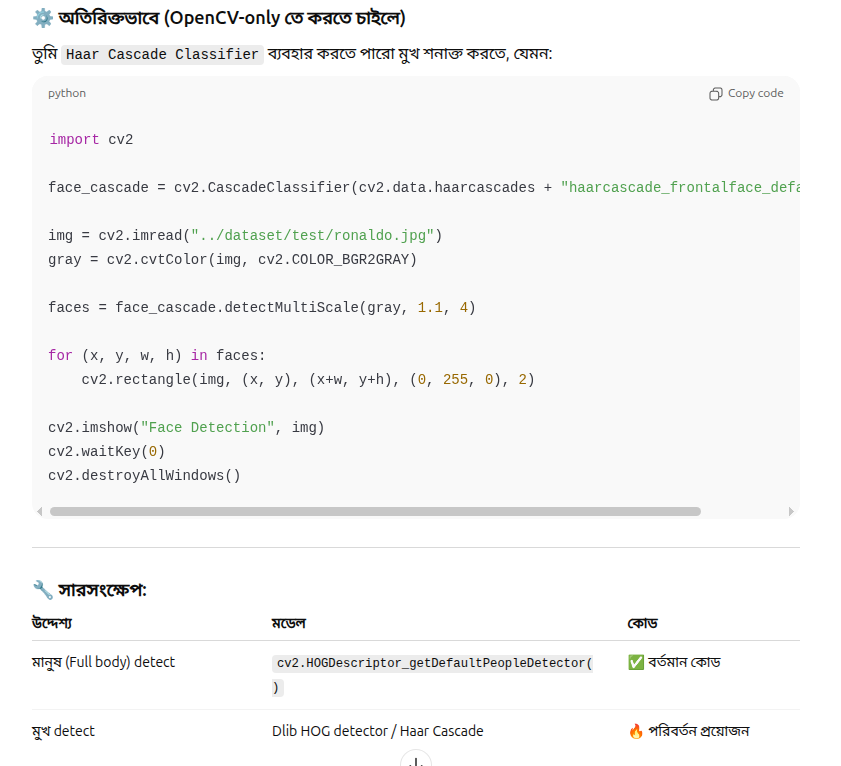

## 1. Single Image Detection

In [1]:
import cv2

# ১. ইমেজ লোড
img = cv2.imread("../dataset/test/ronaldo.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ২. HOG Descriptor তৈরি
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())  # মানুষ সনাক্তকরণের জন্য

# ৩. ডিটেকশন
rects, weights = hog.detectMultiScale(gray, winStride=(8,8))

# ৪. রেকট্যাংগেল ড্র
for (x, y, w, h) in rects:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)

cv2.imshow("HOG Image Detection", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

✅ বিঃদ্রঃ Single image-এর ক্ষেত্রে শুধু একটি ফ্রেম প্রসেস হয়।

## 2. Video Detection (MP4 বা AVI ফাইল)

In [2]:
import cv2

# ১. ভিডিও লোড
cap = cv2.VideoCapture("../dataset/vid/s.mp4")
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    rects, weights = hog.detectMultiScale(gray, winStride=(8,8))

    for (x, y, w, h) in rects:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cv2.imshow("HOG Video Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

✅ ভিডিও প্রসেসিংতে প্রতিটি ফ্রেমকে আলাদাভাবে গ্রেস্কেল, ডিটেকশন এবং ড্র করা হয়।

## 3. Webcam (Live Stream) Detection

In [3]:
import cv2

# ১. Webcam চালু
cap = cv2.VideoCapture(0)  # 0 মানে প্রথম ডিফল্ট ক্যামেরা

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    rects, weights = hog.detectMultiScale(gray, winStride=(8,8))

    for (x, y, w, h) in rects:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    cv2.imshow("HOG Webcam Detection", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):  # q প্রেস করলে বের হবে
        break

cap.release()
cv2.destroyAllWindows()

✅ লাইভ স্ট্রিমে প্রতি ফ্রেমে ডিটেকশন হয় এবং রিয়েল-টাইম দেখানো যায়।

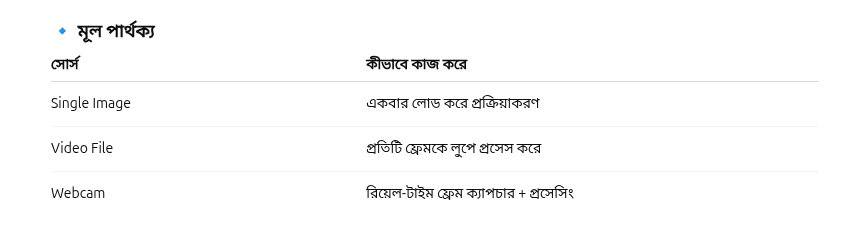

# 2. Tips

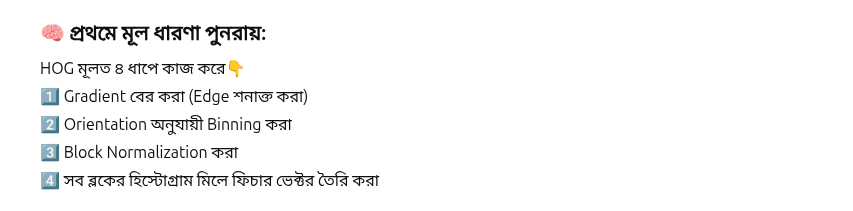

## 1. Single Image: HOG + Gradient Visualization + Feature Vector Extraction

HOG Feature Vector Size: (31752000,)
Sample Feature Values: [0.09331839 0.05269843 0.11608829 0.         0.20101647 0.
 0.03337185 0.01389494 0.09082448 0.15642855]


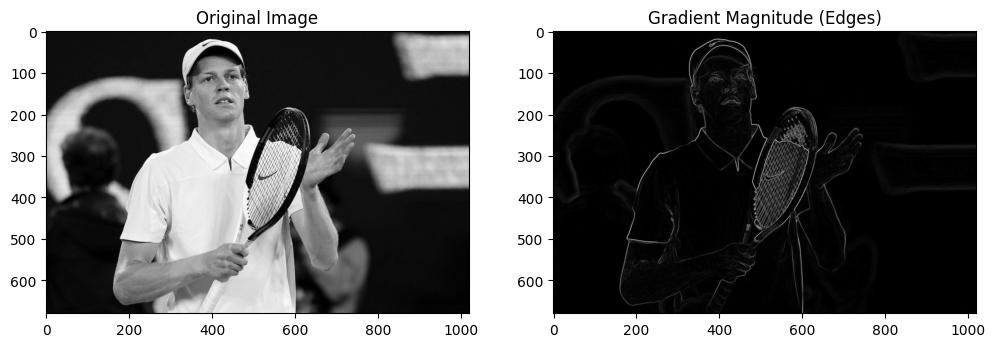

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ইমেজ লোড
img = cv2.imread("../dataset/test/sinner.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Gradient (Edge) বের করা
gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=1)

# Magnitude এবং Orientation বের করা
magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

# HOG Descriptor
hog = cv2.HOGDescriptor()
h, hog_image = hog.compute(gray), None  # Feature Vector বের করা

print("HOG Feature Vector Size:", h.shape)
print("Sample Feature Values:", h[:10].flatten())

# Gradient Visualization
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(gray, cmap='gray')

plt.subplot(1,2,2)
plt.title("Gradient Magnitude (Edges)")
plt.imshow(magnitude, cmap='gray')
plt.show()

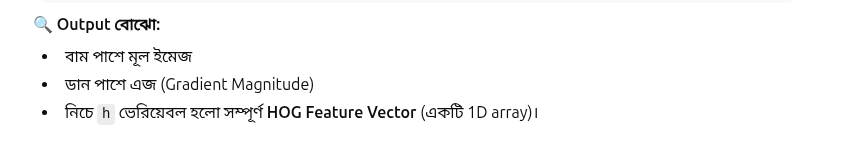

## 2. Video File: প্রতিটি ফ্রেমে HOG Feature বের করা

In [5]:
import cv2
import numpy as np

cap = cv2.VideoCapture("../dataset/vid/s.mp4")
hog = cv2.HOGDescriptor()

frame_no = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Gradient বের করা
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=1)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=1)
    magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

    # HOG Feature Vector
    features = hog.compute(gray)
    print(f"Frame {frame_no}: Feature vector size = {features.shape}")

    cv2.imshow("HOG Video (Edges)", cv2.convertScaleAbs(magnitude))
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
    frame_no += 1

cap.release()
cv2.destroyAllWindows()

Frame 0: Feature vector size = (108864000,)
Frame 1: Feature vector size = (108864000,)
Frame 2: Feature vector size = (108864000,)
Frame 3: Feature vector size = (108864000,)
Frame 4: Feature vector size = (108864000,)
Frame 5: Feature vector size = (108864000,)
Frame 6: Feature vector size = (108864000,)
Frame 7: Feature vector size = (108864000,)
Frame 8: Feature vector size = (108864000,)
Frame 9: Feature vector size = (108864000,)
Frame 10: Feature vector size = (108864000,)
Frame 11: Feature vector size = (108864000,)
Frame 12: Feature vector size = (108864000,)
Frame 13: Feature vector size = (108864000,)
Frame 14: Feature vector size = (108864000,)
Frame 15: Feature vector size = (108864000,)
Frame 16: Feature vector size = (108864000,)
Frame 17: Feature vector size = (108864000,)
Frame 18: Feature vector size = (108864000,)
Frame 19: Feature vector size = (108864000,)
Frame 20: Feature vector size = (108864000,)
Frame 21: Feature vector size = (108864000,)
Frame 22: Feature ve

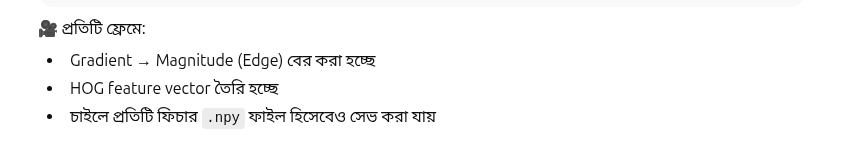

## 3. Webcam: লাইভ HOG + Edge Visualization

In [6]:
import cv2
import numpy as np

cap = cv2.VideoCapture(0)
hog = cv2.HOGDescriptor()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=1)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=1)
    magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

    # ফিচার ভেক্টর বের করা
    features = hog.compute(gray)

    # Gradient visualization (edge)
    vis = cv2.convertScaleAbs(magnitude)
    cv2.imshow("Webcam HOG Gradient", vis)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

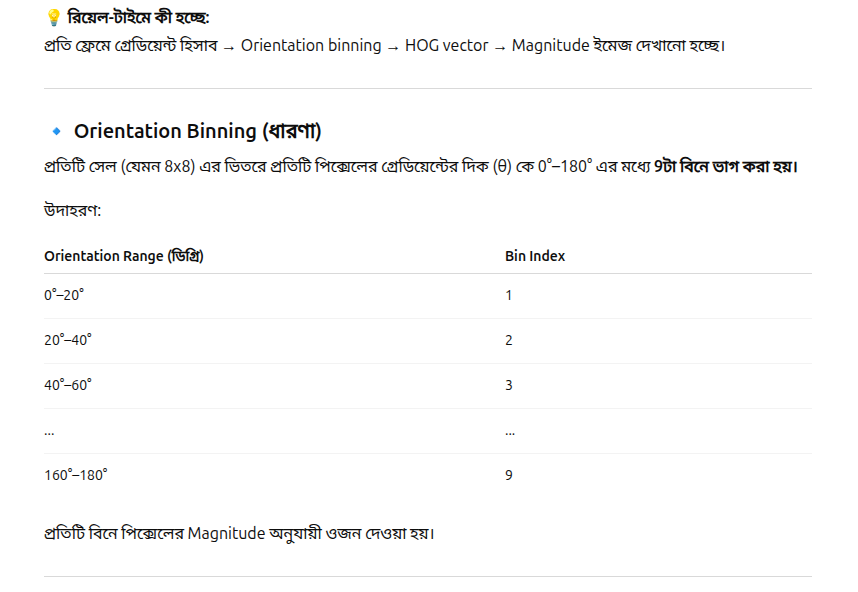

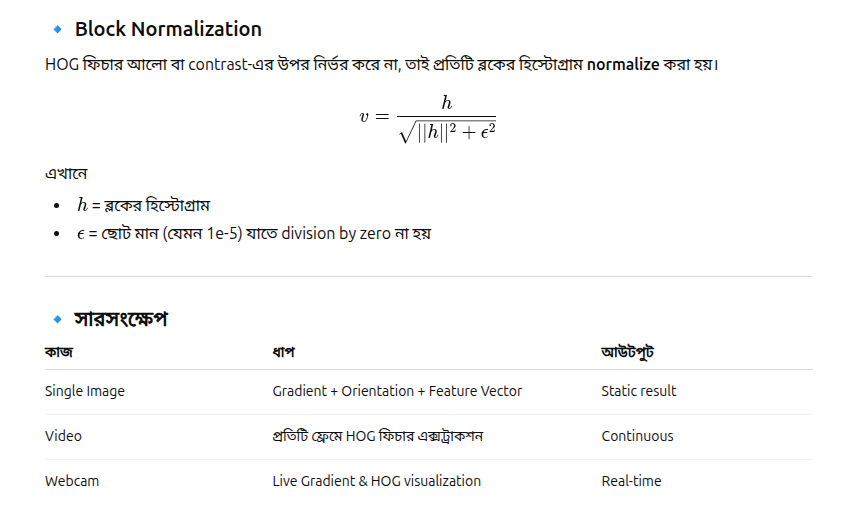